# S02. Coupled Thermal-Orbital Evolution

TidalPy calculates rates, and `System.evolve` integrates them. This notebook evolves a hypothetical Earth-like planet (the bundled `earth_thermal`) about the Sun for 5 Gyr, its thermal state, its spin, and its orbit coupled:

* semi-major axis 0.15 au and eccentricity 0.2;
* an initial spin 10 times its orbital motion;
* tides raised in both the planet and the Sun (`calc_pair_evolution`);
* a mantle whose viscosity follows MatPack peridotite's creep law, which depends on pressure as well as temperature, and whose temperature profile is solved at every state, so its tidal response is the solid Earth's (see [WorldPack](../../Structures/config/worldpack.md));
* tidal and radiogenic heat that warm the planet's layers.

The integration takes about three minutes.

In [1]:
%matplotlib inline
import numpy as np
# The trapezoid rule: np.trapezoid from NumPy 2.0, np.trapz before it.
trapezoid = getattr(np, "trapezoid", None) or np.trapz
import matplotlib.pyplot as plt

from TidalPy.constants import au, year
from TidalPy.Structures import System, build_world
from TidalPy.Utilities.logging import set_log_level

set_log_level("error")   # Every solve logs its molten regions at the info level
MYR = 1.0e6 * year       # [s]

## Building the System

`earth_thermal` is `earth_simple` with a mantle viscosity that rises with pressure (activation volumes of 6 and 15 cm$^3$ mol$^{-1}$), so its solved temperature profile, an adiabat under a conducting lid, gives the Earth's tidal response: an M2 quality factor near 300. `earth_simple`, fitted at a prescribed temperature, softens to a Q of 28 with its profile solved, and a planet built from it melts under far less tidal heat.

The planet pins a radial-solver tolerance of $10^{-10}$, tighter than the default. Near a spin-orbit equilibrium the net tidal torque is a small difference of large mode torques, so it carries the solve's error amplified by about the quality factor, and the tighter solve keeps that noise far below the torque that holds the spin.

The bundled Sun has no spin, so it is given its sidereal rotation. `set_tidal_host(sun, planet)` makes the two a mutual pair, so the planet raises tides on the Sun as well. Each layer's `use_heating` lets the world's heat sources warm it: its radiogenic heat, and the tidal heat of the latest `calc_tides`.

In [2]:
planet = build_world("earth_thermal", {"name": "Planet", "radial_solver": {"rtol": 1.0e-10, "atol": 1.0e-14}})
for layer in planet:
    layer.use_heating = True   # Radiogenic and tidal heat enter each layer

sun = build_world("sol")
sun.set_spin_frequency(2.0 * np.pi / (25.38 * 86400.0))   # Sidereal rotation [rad s-1]

A0 = 0.15 * au      # [m]
E0 = 0.2
SPIN_RATIO0 = 10.0  # Spin frequency / orbital motion

system = System("Exoplanet")
system.add_world(
    sun,
    is_star=True)
system.add_world(
    planet,
    tidal_host=sun,
    semi_major_axis=A0,
    eccentricity=E0)
system.set_tidal_host(sun, planet)   # The planet raises tides on the Sun too

n0 = system.calc_orbital_frequency(planet)   # [rad s-1]
planet.set_spin_frequency(SPIN_RATIO0 * n0)
print(f"orbital period {2.0 * np.pi / n0 / 86400.0:.2f} days, "
      f"equilibrium temperature {system.calc_equilibrium_temperature(planet):.0f} K")
for layer in planet:
    print(f"{layer.name:11} {layer.radius_inner / 1e3:7.1f} to {layer.radius_outer / 1e3:7.1f} km   "
          f"T = {layer.temperature:6.0f} K")

orbital period 21.22 days, equilibrium temperature 661 K
inner_core      0.0 to  1221.5 km   T =   5500 K
outer_core   1221.5 to  3480.0 km   T =   4500 K
mantle       3480.0 to  6371.0 km   T =   1600 K


## Equations

`System.evolve` integrates the semi-major axis $a$, the eccentricity $e$, the Sun's spin $\Omega_\star$, the temperature $T_i$ of each of the planet's layers, and, between spin-orbit equilibria, the planet's spin ratio $s = \Omega / n$:

* $\dot a$, $\dot e$, $\dot\Omega$, and $\dot\Omega_\star$ come from `calc_pair_evolution`, which sums the tides raised in both bodies.
* The spin ratio follows the spin and the orbital motion, $\dot s = (\dot\Omega - s \dot n) / n$ with $\dot n = -\tfrac{3}{2} (n / a) \dot a$.
* Each layer warms at `calc_layer_temperature_rate`: $(C_i + C_{\mathrm{latent},i})\,\dot T_i = L_{\mathrm{in},i} - L_{\mathrm{out},i} + H_i$, with the heat flows and radiogenic heat of `solve_eos(solve_temperature=True)` (convective cooling to the surface included) and the layer's tidal heat from the latest `calc_tides`. $C_i$ is the heat the layer's solved profile stores per kelvin of its temperature, $\rho c_p$ integrated over the layer and weighted by how far each point moves with the layer's temperature, with the latent heat where the profile is partially molten. Every state solves the EOS again, with the radiogenic heat at the integration time.
* The surface sits at the planet's equilibrium temperature under the Sun's orbit-averaged insolation.

## Spin-Orbit Equilibria

Each degree-2 tidal mode forces the planet at $(2 - 2p + q)\,n - 2\Omega$, which vanishes at a half-integer spin ratio $s = k/2$. As the spin crosses $k/2$, that mode's torque changes sign. For a viscoelastic planet this torque can outweigh every other mode near $k/2$, which makes a stable spin equilibrium: spin-up just below it and spin-down just above it (Makarov and Efroimsky 2013). The orbit-averaged spin equation is first order, so a despinning planet that reaches one stays, without a permanent (triaxial) figure.

In this planet's cold mantle the equilibria are narrow. The 5:2 equilibrium sits about $10^{-6}$ below $k/2$, between the torque's peaks, and the spin relaxes onto it within a year, while the orbit and the mantle change over Myr. An implicit integrator carrying $s$ at a tolerance of $10^{-4}$ steps straight over it, and one that resolves it takes year-long steps for 5 Gyr. `System.evolve` therefore tracks the spin. Between equilibria $s$ is integrated (*free*). On one, $s$ is set to the equilibrium of each state (*tracked*), found by a root search of the spin balance $\dot s(s)$, and the rates are the combination of the root's two sides that zeroes the balance (Filippov's convex combination), so the spin and the orbit take one torque. The captures, the windows that hold a tracked spin, and the releases when an equilibrium vanishes with its unstable neighbor are integration events (see [System](../../Structures/system/system.md)).

## Integrating 5 Gyr

`evolve` returns every step it took. Its `segments` log each stretch of the integration: the captures, the releases, and the recenterings of a held spin's window as its equilibrium drifts.

In [3]:
T_END = 5000.0   # [Myr]
result = system.evolve(planet, (0.0, T_END * MYR))
print(result.message)
print(f"{result.time.size} steps, {len(result.segments)} segments, {result.num_tide_solves} tide solves, "
      f"{result.elapsed:.0f} s")

print("\ntime [Myr]   event")
held = False
for segment in result.segments:
    if (segment["mode"] == "tracked") and not held:
        print(f"{segment['time'] / MYR:10.4g}   held at s = {segment['root']:.8f}")
    elif (segment["mode"] != "tracked") and held:
        print(f"{segment['time'] / MYR:10.4g}   released at s = {segment['spin_ratio']:.8f}")
    held = segment["mode"] == "tracked"

TidalPy: System.evolve reached the end of its span.
472 steps, 69 segments, 12054 tide solves, 177 s

time [Myr]   event
    0.9987   held at s = 2.49999904
     9.387   released at s = 2.49999672
     9.422   held at s = 1.99999977
     59.93   released at s = 1.99765482
     59.95   held at s = 1.49986355
     62.07   released at s = 1.49973351
     62.12   held at s = 1.00000035


## Diagnostics

Each step carries the planet's tidal heating and spin. The mantle's melt, viscosity, and shear modulus, and the radiogenic heat, belong to the solved structure, so the EOS is solved again at 120 steps spaced logarithmically in time. The mantle quantities are averaged over its volume: its melt fraction, the fraction of it the Love solve takes as liquid (where melt has left it too weak to be solved as a solid), and over the rest, the solid part, the viscosity and shear modulus geometrically (as means of their logarithms), since melt changes them by orders of magnitude.

In [4]:
time_myr = result.time / MYR
mantle = planet.mantle
# Midpoints of 2000 shells: the mantle's base radius also belongs to the liquid outer core below it.
mantle_radii = mantle.radius_inner + (mantle.radius_outer - mantle.radius_inner) * (np.arange(2000) + 0.5) / 2000
volume_weight = mantle_radii**2 / trapezoid(mantle_radii**2, mantle_radii)


def mantle_mean(values, logarithmic=False, where=None):
    # Volume mean over the mantle, or over its points `where` is True; geometric with `logarithmic`
    weight = volume_weight if where is None else volume_weight * where
    values = np.log10(np.where(weight > 0.0, values, 1.0)) if logarithmic else values
    mean = trapezoid(values * weight, mantle_radii) / trapezoid(weight, mantle_radii)
    return 10.0**mean if logarithmic else mean


samples = np.unique(np.searchsorted(time_myr, np.geomspace(1.0e-3, T_END, 120)).clip(0, time_myr.size - 1))
history = {key: [] for key in ("radiogenic", "melt", "liquid", "viscosity", "shear")}
for step in samples:
    system.set_semi_major_axis(planet, result.semi_major_axis[step])
    system.set_eccentricity(planet, result.eccentricity[step])
    for layer, temperature in zip(planet, result.temperature[:, step]):
        layer.temperature = temperature
    planet.clear_tidal_heating()
    thermal = planet.solve_eos(
        solve_temperature=True,
        surface_temperature=system.calc_equilibrium_temperature(planet),
        time=result.time[step])
    history["radiogenic"].append(np.sum(thermal["layer_heating_radiogenic"]))
    shear = planet.get_shear_modulus(mantle_radii)
    solid = shear > 0.0   # The Love solve takes the rest as liquid
    history["melt"].append(mantle_mean(planet.get_melt_fraction(mantle_radii)))
    history["liquid"].append(1.0 - mantle_mean(solid.astype(float)))
    history["viscosity"].append(mantle_mean(planet.get_shear_viscosity(mantle_radii), logarithmic=True, where=solid))
    history["shear"].append(mantle_mean(shear, logarithmic=True, where=solid))
history = {key: np.asarray(value) for key, value in history.items()}

mantle_temperature = result.temperature[-1]
plotted = time_myr >= 1.0e-3   # The log time axis starts at 1 kyr
for label, index in (("start", 0), ("end", -1)):
    print(f"{label:5}: a = {result.semi_major_axis[index] / au:.6f} au, e = {result.eccentricity[index]:.4f}, "
          f"spin/n = {result.spin_ratio[index]:.6f}, upper mantle T = {mantle_temperature[index]:.0f} K, "
          f"tidal heating = {result.tidal_heating[index]:.2e} W")
for key, extreme in (("melt", np.argmax), ("liquid", np.argmax), ("viscosity", np.argmin)):
    at = extreme(history[key])
    print(f"{key:9} {'peak' if extreme is np.argmax else 'least'} {history[key][at]:.3g} at {time_myr[samples][at]:.4g} Myr")

start: a = 0.150000 au, e = 0.2000, spin/n = 10.000000, upper mantle T = 1600 K, tidal heating = 1.60e+15 W
end  : a = 0.149569 au, e = 0.1930, spin/n = 1.000000, upper mantle T = 1886 K, tidal heating = 3.31e+14 W
melt      peak 0.112 at 302.2 Myr
liquid    peak 0.0402 at 261.2 Myr
viscosity least 1.84e+17 at 334.5 Myr


## Orbit

The orbit changes little over 5 Gyr: $a$ falls by 0.29 percent and $e$ (dashed) from 0.200 to 0.193. The planet's tides draw the energy they dissipate from the orbit (the spin, held at a fixed ratio to the orbital motion, stores almost none of it), so $a$ and $e$ fall together, and most of the change comes in the last few Gyr, at the synchronous planet's steady heating of about $3 \times 10^{14}$ W.

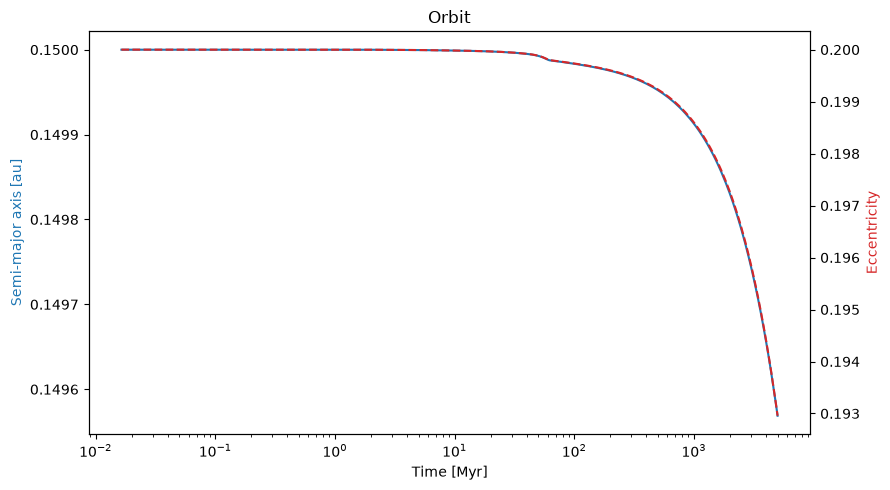

In [5]:
fig, ax_a = plt.subplots(figsize=(9, 5))
ax_e = ax_a.twinx()
ax_a.plot(time_myr[plotted], result.semi_major_axis[plotted] / au, color="tab:blue")
ax_e.plot(time_myr[plotted], result.eccentricity[plotted], color="tab:red", ls="--")
ax_a.set_xscale("log")
ax_a.set_xlabel("Time [Myr]")
ax_a.set_ylabel("Semi-major axis [au]", color="tab:blue")
ax_e.set_ylabel("Eccentricity", color="tab:red")
ax_a.set_title("Orbit")
fig.tight_layout()
plt.show()

## Spin

The planet despins from 10 times its orbital motion in 1 Myr, passing each half-integer ratio down to 3:1 (at each, the capture test finds no equilibrium the spin reaches), and is held at 5:2, $10^{-6}$ below it. The cold mantle's equilibria sit this close to $k/2$, between the peaks of the resonant mode's torque, with an unstable equilibrium a few $10^{-6}$ below. As the mantle warms, the stable equilibrium moves down toward the unstable one until the two meet and vanish, and the spin is released to the next ratio below: 5:2 at 9.4 Myr, 2:1 at 59.9 Myr (by then $2.4 \times 10^{-3}$ below 2), and 3:2 at 62.1 Myr. From 62 Myr the planet is synchronous, $3.5 \times 10^{-7}$ above 1:1. The shading marks where the spin is held.

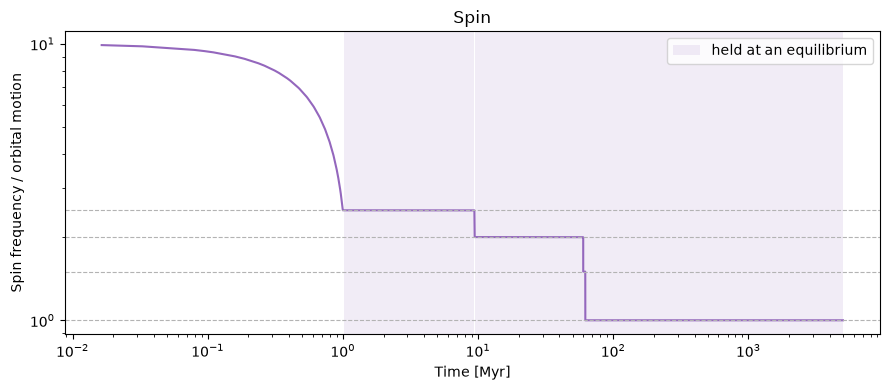

In [6]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(time_myr[plotted], result.spin_ratio[plotted], color="tab:purple")
ax.fill_between(time_myr[plotted], 0.0, 1.0, where=result.tracked[plotted], transform=ax.get_xaxis_transform(),
                color="tab:purple", alpha=0.12, lw=0, label="held at an equilibrium")
for ratio in (1.0, 1.5, 2.0, 2.5):
    ax.axhline(ratio, color="0.7", lw=0.8, ls="--")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Time [Myr]")
ax.set_ylabel("Spin frequency / orbital motion")
ax.set_title("Spin")
ax.legend(loc="upper right")
fig.tight_layout()
plt.show()

## Heating, Temperature, and Melt

Tidal heating starts at $1.6 \times 10^{15}$ W while the planet spins fast and falls as it despins. At each held ratio it rises as the mantle warms and softens toward the viscosity at which it dissipates most, peaking at $2.2 \times 10^{15}$ W just before 2:1 vanishes. The radiogenic heat, $1.8 \times 10^{14}$ W at first, is a fraction of it. The upper mantle warms from 1600 to about 1910 K by 300 Myr and partially melts, to a volume-mean melt fraction of 11 percent, with 4 percent of the mantle melted enough that the Love solve takes it as liquid. It then cools by about 25 K over the remaining 4.7 Gyr as the radiogenic heat decays, while convection carries off the synchronous planet's tidal heat (about 0.65 W m$^{-2}$ at the surface, eight times the Earth's heat flow): a tidal-convective equilibrium, which `earth_thermal`'s pressure-dependent viscosity reaches without the mantle running away into a magma ocean.

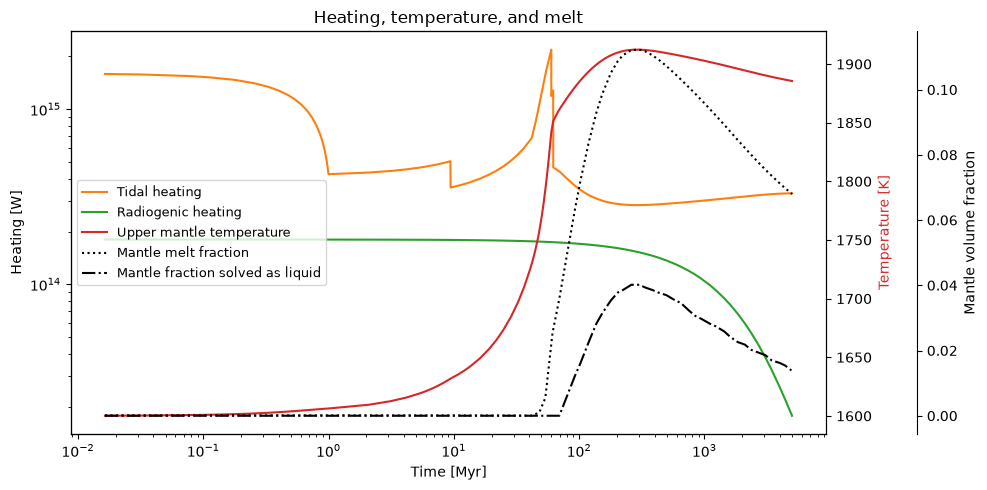

In [7]:
fig, ax_heat = plt.subplots(figsize=(10, 5))
ax_temperature = ax_heat.twinx()
ax_melt = ax_heat.twinx()
ax_melt.spines["right"].set_position(("axes", 1.12))

ax_heat.plot(time_myr[plotted], result.tidal_heating[plotted], color="tab:orange", label="Tidal heating")
ax_heat.plot(time_myr[samples], history["radiogenic"], color="tab:green", label="Radiogenic heating")
ax_temperature.plot(time_myr[plotted], mantle_temperature[plotted], color="tab:red", label="Upper mantle temperature")
ax_melt.plot(time_myr[samples], history["melt"], color="black", ls=":", label="Mantle melt fraction")
ax_melt.plot(time_myr[samples], history["liquid"], color="black", ls="-.", label="Mantle fraction solved as liquid")

ax_heat.set_xscale("log")
ax_heat.set_yscale("log")
ax_heat.set_xlabel("Time [Myr]")
ax_heat.set_ylabel("Heating [W]")
ax_temperature.set_ylabel("Temperature [K]", color="tab:red")
ax_melt.set_ylabel("Mantle volume fraction")
handles = [line for axis in (ax_heat, ax_temperature, ax_melt) for line in axis.get_lines()]
ax_heat.legend(handles, [line.get_label() for line in handles], loc="center left", fontsize=9)
ax_heat.set_title("Heating, temperature, and melt")
fig.tight_layout()
plt.show()

## Viscosity and Shear Modulus

The solid mantle's viscosity (geometric mean) falls from $3 \times 10^{21}$ Pa s by more than four orders of magnitude as it warms and melts, to $1.8 \times 10^{17}$ Pa s near 330 Myr, and then rises slowly as it cools. Its shear modulus falls only where melt weakens it (the Henning model), by about 30 percent in the mean over the solid part; the most weakened shells, beside those taken as liquid, carry most of that drop.

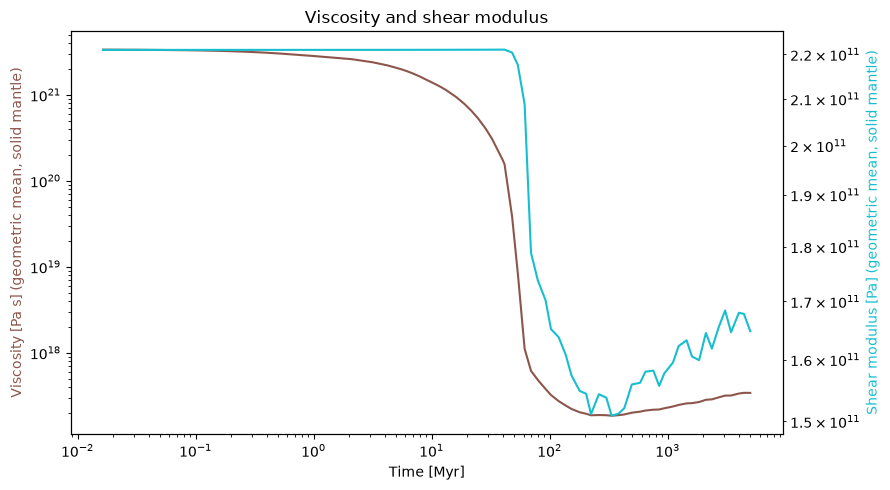

In [8]:
fig, ax_viscosity = plt.subplots(figsize=(9, 5))
ax_shear = ax_viscosity.twinx()
ax_viscosity.plot(time_myr[samples], history["viscosity"], color="tab:brown")
ax_shear.plot(time_myr[samples], history["shear"], color="tab:cyan")
ax_viscosity.set_xscale("log")
ax_viscosity.set_yscale("log")
ax_shear.set_yscale("log")
ax_viscosity.set_xlabel("Time [Myr]")
ax_viscosity.set_ylabel("Viscosity [Pa s] (geometric mean, solid mantle)", color="tab:brown")
ax_shear.set_ylabel("Shear modulus [Pa] (geometric mean, solid mantle)", color="tab:cyan")
ax_viscosity.set_title("Viscosity and shear modulus")
fig.tight_layout()
plt.show()

## Discussion

Held at its spin-orbit equilibria, this Earth-like planet spends its first 60 Myr at 5:2 and 2:1 with its mantle warming, and the rest of its 5 Gyr synchronous, with its upper mantle partially molten and its tidal heat, about $3 \times 10^{14}$ W, carried off by convection.

The equilibria are why the integration needs `System.evolve`. Integrated directly, with the spin as one more variable, the same system takes LSODA about five minutes and a different path: at a tolerance of $10^{-4}$ the spin steps over the 5:2 and 2:1 equilibria (each a few $10^{-6}$ wide), and near the warm 3:2 equilibrium the integrator wanders for 10000 evaluations and accepts a step that raises $a$ by 1 percent, an orbit that gains energy while the planet dissipates it. Tracked, the spin costs a root search at each evaluation (about 26 tide solves per step here), the orbit and the mantle set the steps, and over 10 to 200 Myr the orbit loses 0.98 times the planet's integrated tidal heat.

Caveats:

* A tracked spin sits exactly on its equilibrium. The neglected lag is its relaxation time (years) over the evolution time.
* The planet has no permanent (triaxial) figure, which would add a resonant torque of its own.
* Melt only weakens the mantle. Regions molten past the liquid threshold are static liquid in the tidal solve, and melt carries no heat upward by itself (there is no heat-pipe advection); the convection model's magma-ocean scaling takes over only where the interior is liquid.
* The Sun's spin evolves freely, under its fixed-Q tide.

**References**

* Filippov, A. F. (1988). *Differential Equations with Discontinuous Righthand Sides*. Kluwer Academic Publishers.
* Henning, W. G., O'Connell, R. J., and Sasselov, D. D. (2009). Tidally heated terrestrial exoplanets: Viscoelastic response models. *The Astrophysical Journal*, 707(2), 1000-1015.
* Hirth, G., and Kohlstedt, D. (2003). Rheology of the upper mantle and the mantle wedge: A view from the experimentalists. In *Inside the Subduction Factory*, Geophysical Monograph 138, 83-105. American Geophysical Union.
* Makarov, V. V., and Efroimsky, M. (2013). No pseudosynchronous rotation for terrestrial planets and moons. *The Astrophysical Journal*, 764(1), 27.
* Monteux, J., Andrault, D., and Samuel, H. (2016). On the cooling of a deep terrestrial magma ocean. *Earth and Planetary Science Letters*, 448, 140-149.
* Walterová, M., and Běhounková, M. (2020). Thermal and orbital evolution of low-mass exoplanets. *The Astrophysical Journal*, 900(1), 24.